In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [33]:
df = pd.read_csv("diabetic_data.csv")

In [34]:
df = df.drop(columns=["encounter_id", "patient_nbr"], errors="ignore")

In [35]:
df.isna().sum(axis=0).sort_values(ascending=False).head(5)

max_glu_serum        96420
A1Cresult            84748
race                     0
gender                   0
admission_type_id        0
dtype: int64

In [36]:
df["max_glu_serum"] = df["max_glu_serum"].fillna("not_measured")
df["A1Cresult"] = df["A1Cresult"].fillna("not_measured")

In [37]:
for col in df.columns:
    print(df[col].value_counts())
    print(df[col].dtype)
    print()

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
str

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
str

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64
str

weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64
str

admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64
int64

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      118

In [38]:
df = df[df["gender"] != "Unknown/Invalid"]
df = df[~df["discharge_disposition_id"].isin([11, 13, 14, 19, 20, 21])] # смерть/хоспис
df = df.replace("?", np.nan)

In [39]:
df["admission_type_id"] = df["admission_type_id"].astype(str)
df["discharge_disposition_id"] = df["discharge_disposition_id"].astype(str)
df["admission_source_id"] = df["admission_source_id"].astype(str)

In [40]:
y = (df["readmitted"] == "<30").astype(int)
X = df.drop(columns=["readmitted", "weight", 'examide', 'citoglipton'], errors="ignore")

In [41]:
X.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),6,25,1,1,NaN,Pediatrics-Endocrinology,41,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),1,1,7,3,NaN,NaN,59,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,NaN,11,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),1,1,7,2,NaN,NaN,44,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),1,1,7,1,NaN,NaN,51,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [42]:
y.mean()

np.float64(0.1138916851218039)

In [43]:
age_mapping = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

X["age_mid"] = X["age"].map(age_mapping)

In [44]:
def map_icd9(code):

    if pd.isna(code):
        return 'Missing'

    code = str(code).strip()

    if code.startswith('V'):
        return 'Supplementary_Factors'

    if code.startswith('E'):
        return 'External_Causes'

    try:
        num = float(code)
    except ValueError:
        return 'Unknown'

    if 1 <= num <= 139:
        return 'Infectious_Parasitic'

    elif 140 <= num <= 239:
        return 'Neoplasms'

    elif 240 <= num <= 279:
        return 'Endocrine_Metabolic_Immunity'

    elif 280 <= num <= 289:
        return 'Blood_Diseases'

    elif 290 <= num <= 319:
        return 'Mental_Disorders'

    elif 320 <= num <= 389:
        return 'Nervous_Sense_Organs'

    elif 390 <= num <= 459:
        return 'Circulatory'

    elif 460 <= num <= 519:
        return 'Respiratory'

    elif 520 <= num <= 579:
        return 'Digestive'

    elif 580 <= num <= 629:
        return 'Genitourinary'

    elif 630 <= num <= 679:
        return 'Pregnancy_Childbirth'

    elif 680 <= num <= 709:
        return 'Skin_Subcutaneous'

    elif 710 <= num <= 739:
        return 'Musculoskeletal'

    elif 740 <= num <= 759:
        return 'Congenital_Anomalies'

    elif 760 <= num <= 779:
        return 'Perinatal'

    elif 780 <= num <= 799:
        return 'Symptoms_IllDefined'

    elif 800 <= num <= 999:
        return 'Injury_Poisoning'

    else:
        return 'Unknown'

for col in ["diag_1", "diag_2", "diag_3"]:
    X[col + "_group"] = X[col].apply(map_icd9)

In [45]:
X["prior_visits"] = X["number_outpatient"] + X["number_emergency"] + X["number_inpatient"]

X["had_prior_inpatient"] = (X["number_inpatient"] > 0).astype(int)

X["treatment_intensity"] = X["num_lab_procedures"] + X["num_procedures"] + X["num_medications"]

X["many_medications"] = (X["num_medications"] >= X["num_medications"].quantile(0.75)).astype(int)

X["long_stay"] = (X["time_in_hospital"] >= X["time_in_hospital"].quantile(0.75)).astype(int)

In [46]:
cat_features = X.select_dtypes(include=["str"]).columns.tolist()
num_features = X.select_dtypes(exclude=["str"]).columns.tolist()

In [47]:
for col in cat_features:
    X[col] = X[col].fillna("missing")

for col in num_features:
    X[col] = X[col].fillna(X[col].median())

In [48]:
from sklearn.model_selection import train_test_split

X_train_val, X_test_cal, y_train_val, y_test_cal = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=52
)

X_test, X_cal, y_test, y_cal = train_test_split(
    X_test_cal,
    y_test_cal,
    test_size=0.5,
    stratify=y_test_cal,
    random_state=52
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    stratify=y_train_val,
    random_state=52
)

In [49]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(
    X_train,
    y_train,
    cat_features=cat_features
)

valid_pool = Pool(
    X_val,
    y_val,
    cat_features=cat_features
)

cal_pool = Pool(
    X_cal,
    y_cal,
    cat_features=cat_features
)

test_pool = Pool(
    X_test,
    y_test,
    cat_features=cat_features
)

In [50]:
cb_model = CatBoostClassifier(
    iterations = 3000,
    learning_rate = 0.05,
    loss_function = "Logloss",
    eval_metric = "AUC",
    depth = 4,
    l2_leaf_reg = 5,
    auto_class_weights = "SqrtBalanced",
    random_seed = 52,
    early_stopping_rounds = 100,
    verbose = 100,
    allow_writing_files = False
)

cb_model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

0:	test: 0.6251382	best: 0.6251382 (0)	total: 244ms	remaining: 12m 11s
100:	test: 0.6735057	best: 0.6735057 (100)	total: 5.41s	remaining: 2m 35s
200:	test: 0.6773277	best: 0.6773407 (198)	total: 10.9s	remaining: 2m 32s
300:	test: 0.6796364	best: 0.6796373 (299)	total: 16.7s	remaining: 2m 30s
400:	test: 0.6809786	best: 0.6809786 (400)	total: 29.2s	remaining: 3m 9s
500:	test: 0.6810739	best: 0.6812233 (420)	total: 44.6s	remaining: 3m 42s
600:	test: 0.6815951	best: 0.6816176 (574)	total: 1m	remaining: 4m
700:	test: 0.6817851	best: 0.6818221 (658)	total: 1m 16s	remaining: 4m 10s
800:	test: 0.6818789	best: 0.6819350 (784)	total: 1m 32s	remaining: 4m 15s
900:	test: 0.6820100	best: 0.6822478 (846)	total: 1m 49s	remaining: 4m 14s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6822478169
bestIteration = 846

Shrink model to first 847 iterations.


CatBoostClassifier(allow_writing_files=False, auto_class_weights='SqrtBalanced', depth=4, early_stopping_rounds=100, eval_metric='AUC', iterations=3000, l2_leaf_reg=5, learning_rate=0.05, loss_function='Logloss', random_seed=52, verbose=100)

In [51]:
best_iteration = cb_model.get_best_iteration()

final_cb_model = CatBoostClassifier(
    iterations=best_iteration + 1,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    depth = 4,
    l2_leaf_reg = 5,
    auto_class_weights = "SqrtBalanced",
    random_seed=52,
    verbose=100,
    allow_writing_files=False
)

final_train_pool = Pool(X_train_val, y_train_val, cat_features=cat_features)

final_cb_model.fit(final_train_pool)

0:	total: 55.9ms	remaining: 47.3s
100:	total: 6.03s	remaining: 44.6s
200:	total: 12.2s	remaining: 39.1s
300:	total: 18.3s	remaining: 33.2s
400:	total: 24.5s	remaining: 27.2s
500:	total: 30.6s	remaining: 21.2s
600:	total: 37.1s	remaining: 15.2s
700:	total: 43.7s	remaining: 9.09s
800:	total: 50.2s	remaining: 2.88s
846:	total: 53.3s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, auto_class_weights='SqrtBalanced', depth=4, eval_metric='AUC', iterations=847, l2_leaf_reg=5, learning_rate=0.05, loss_function='Logloss', random_seed=52, verbose=100)

In [52]:
def evaluate_proba(y_true, proba):
    print("ROC AUC:", roc_auc_score(y_true, proba))
    print("PR AUC:", average_precision_score(y_true, proba))
    print("Mean predicted probability:", proba.mean())
    print("Real positive rate:", y_true.mean())
    print()


def evaluate_classification(y_true, y_pred_proba, threshold):
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    print("Threshold:", threshold)
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1:", f1_score(y_true, y_pred, zero_division=0))
    print()
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()
    print("Classification report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print()

In [53]:
y_pred_test_proba = final_cb_model.predict_proba(test_pool)[:, 1]
y_pred_cal_proba = final_cb_model.predict_proba(cal_pool)[:, 1]

evaluate_proba(y_test, y_pred_test_proba)
evaluate_classification(y_test, y_pred_test_proba, threshold=0.113)

ROC AUC: 0.6784095353687396
PR AUC: 0.24945372348835287
Mean predicted probability: 0.2483941795817419
Real positive rate: 0.11388497416280786

Threshold: 0.113
Precision: 0.11853064711326262
Recall: 0.981143193871538
F1: 0.21150914634146342

Confusion matrix:
[[  822 12382]
 [   32  1665]]

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.06      0.12     13204
           1       0.12      0.98      0.21      1697

    accuracy                           0.17     14901
   macro avg       0.54      0.52      0.16     14901
weighted avg       0.87      0.17      0.13     14901




In [56]:
eps = 1e-6

cat_logit_cal = np.log(np.clip(y_pred_cal_proba, eps, 1 - eps) / (1 - np.clip(y_pred_cal_proba, eps, 1 - eps))).reshape(-1, 1)
cat_logit_test = np.log(np.clip(y_pred_test_proba, eps, 1 - eps) / (1 - np.clip(y_pred_test_proba, eps, 1 - eps))).reshape(-1, 1)

In [57]:
from sklearn.linear_model import LogisticRegression

calibrator = LogisticRegression()
calibrator.fit(cat_logit_cal, y_cal)
cat_proba_test_calibrated = calibrator.predict_proba(cat_logit_test)[:, 1]

In [58]:
evaluate_proba(y_test, cat_proba_test_calibrated)

evaluate_classification(y_test, cat_proba_test_calibrated, threshold=0.113)

ROC AUC: 0.6784095353687396
PR AUC: 0.24945372348835287
Mean predicted probability: 0.11451830290873996
Real positive rate: 0.11388497416280786

Threshold: 0.113
Precision: 0.18207075384330432
Recall: 0.5792575132586918
F1: 0.27705749718151074

Confusion matrix:
[[8788 4416]
 [ 714  983]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.77     13204
           1       0.18      0.58      0.28      1697

    accuracy                           0.66     14901
   macro avg       0.55      0.62      0.53     14901
weighted avg       0.84      0.66      0.72     14901




In [59]:
test_results = X_test.copy()
test_results["target"] = y_test.values
test_results["predicted_risk"] = cat_proba_test_calibrated

In [ ]:
test_results.to_csv('model_hypo.csv', index=False)

In [62]:
test_results = pd.read_csv('model_hypo.csv')

Итак, теперь перейдем к гипотезам. Для начала проверим, что модель статистически значимо ранжирует пациентов по риску повторной госпитализации, т.е. мы проверяем, получают ли пациенты, которые фактически были повторно госпитализированы, более высокие значения predicted_risk

Н0 - Распределение predicted_risk одинаково у пациентов с target = 1 и target = 0 (эквивалентная интерпретация: ROC-AUC = 0.5)

Н1 - Распределение predicted_risk у пациентов с target = 1 сдвинуто вправо относительно пациентов с target = 0 (эквивалентная интерпретация: ROC-AUC > 0.5)

В качестве статистического теста используем односторонний тест [Манна-Уитни U](https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test). Это непараметрический тест для сравнения двух независимых выборок. Он подходит здесь, потому что мы сравниваем распределения риска у двух групп пациентов и не предполагаем нормальность predicted_risk

In [63]:
from scipy.stats import mannwhitneyu

risk_positive = test_results.loc[test_results["target"] == 1, "predicted_risk"]

risk_negative = test_results.loc[test_results["target"] == 0, "predicted_risk"]

mannwhitneyu(risk_positive, risk_negative, alternative="greater")

MannwhitneyuResult(statistic=np.float64(15201250.0), pvalue=np.float64(3.212300441414406e-127))

p-value оказалось значительно меньше 0.05, поэтому нулевая гипотеза отвергается - распределения отличаются и это означает что ROC-AUC > 0.5. Почему? ROC-AUC можно понимать очень просто: берем случайного пациента, который вернулся, и случайного пациента, который не вернулся. Смотрим, кому модель дала больший риск. Так делаем для всех возможных пар, и ROC-AUC будет доле таких пар где риск выше у пациента с target=1 среди всех возможных пар. Тест Манна-Уитни считает специальную величину U statistic, и оно как раз и связано с количеством таких пар. Мы можем в этом легко убедиться поделив его на общее количество пар

In [64]:
15201250.0 / (len(risk_negative) * len(risk_positive))

0.6784095353687397

Это как раз и равно нашему ROC-AUC. Также посмотрим визуально:

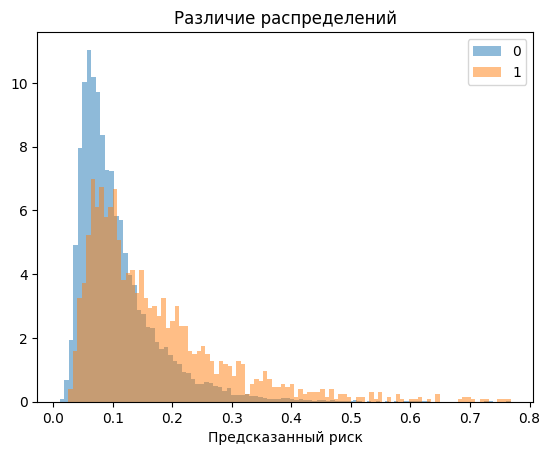

In [65]:
plt.hist(
    risk_negative,
    bins=100,
    alpha=0.5,
    density=True,
    label="0"
)

plt.hist(
    risk_positive,
    bins=100,
    alpha=0.5,
    density=True,
    label="1"
)

plt.xlabel("Предсказанный риск")
plt.title("Различие распределений")
plt.legend()
plt.show()

Отлично, мы убедились, что модель действительно извлекает полезный сигнал, изучим само распределение predicted_risk. Если распределение риска можно описать одним простым распределением, то пациенты скорее образуют одну относительно однородную массу. В таком случае можно использовать один общий порог риска. Если же распределение риска плохо описывается одним простым распределением и лучше аппроксимируется смесью нескольких компонент, это означает, что пациенты неоднородны. Тогда для бизнеса логичнее использовать сегментацию: low-risk, medium-risk, high-risk, и назначать разные уровни сопровождения.

Так как predicted_risk является вероятностью и лежит в интервале от 0 до 1, мы сначала применяем logit-преобразование:

In [66]:
eps = 1e-6
risk_clipped = np.clip(test_results["predicted_risk"].values, eps, 1 - eps)

test_results["logit_predicted_risk"] = np.log(risk_clipped / (1 - risk_clipped))

<Axes: >

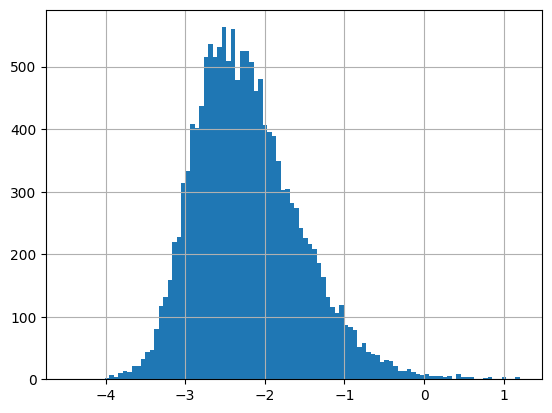

In [67]:
test_results["logit_predicted_risk"].hist(bins=100)

Проверим является ли распредение нормальным:

H0 - logit(predicted_risk) имеет нормальное распределение.

H1 - logit(predicted_risk) не имеет нормального распределения.

Поскольку мы нестандартно мыслим будем использовать [тест Д’Агостино - Пирсона](https://real-statistics.com/tests-normality-and-symmetry/statistical-tests-normality-symmetry/dagostino-pearson-test/). Он проверяет нормальность распределения через асимметрию и эксцесс. Если p-value меньше 0.05, мы отвергаем гипотезу нормальности.

In [68]:
from scipy import stats

stats.normaltest(test_results["logit_predicted_risk"])

NormaltestResult(statistic=np.float64(1187.366454597848), pvalue=np.float64(1.4677442428758787e-258))

p-value оказался намного меньше 0.05, поэтому мы отвергаем H0 о нормальности logit(predicted_risk). Дополнительно используем Q-Q plot для визуальной проверки отклонений от нормального распределения:

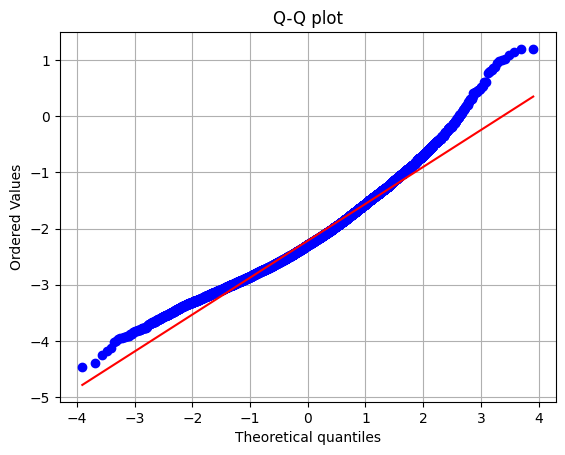

In [69]:
stats.probplot(
    test_results["logit_predicted_risk"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q plot")
plt.grid(True)
plt.show()

Q-Q plot также показывает заметные отклонения от прямой, особенно в хвостах распределения. Следовательно, несмотря на визуальную похожесть, распределение риска не описывается простой logit-normal моделью. Проверим, можно ли лучше описать распределение риска как смесь нескольких logit-normal распределений. В бизнес-интерпретации компоненты смеси можно рассматривать как естественные risk-сегменты пациентов.

In [70]:
from sklearn.mixture import GaussianMixture

X_logit = test_results["logit_predicted_risk"].values.reshape(-1, 1)

gmm_results = []

for n_components in [1, 2, 3, 4, 5]:
    gmm = GaussianMixture(n_components=n_components, random_state=52)
    gmm.fit(X_logit)
    
    print("Компонент:", n_components)
    print("BIC", gmm.bic(X_logit))
    print()

Компонент: 1
BIC 30143.9802072106

Компонент: 2
BIC 29228.37617810467

Компонент: 3
BIC 29279.390580911073

Компонент: 4
BIC 29300.234382739436

Компонент: 5
BIC 29320.521348278427



BIC оказался минимальным при модели с двумя компонентами. Это означает, что распределение logit(predicted_risk) лучше описывается не одной нормальной компонентой, а смесью двух компонент. Проверим согласуются ли данные с двухкомпонентной GMM:

Пусть Z = logit(predicted_risk)

H0: Z ~ p1 * N(mu1, sigma1^2) + p2 * N(mu2, sigma2^2), где p1 + p2 = 1, p1 > 0, p2 > 0, а параметры смеси оцениваются по данным.

H1: распределение Z не может быть описано двухкомпонентной гауссовской смесью

Для практической проверки обучим GMM(2), сгенерируем из нее искусственную выборку того же размера и сравним распределения реальной и сгенерированной выборок с помощью [двухвыборочного критерия Колмогорова-Смирнова](https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test?ysclid=mpke3q81ah194103818).

In [71]:
from scipy.stats import ks_2samp

gmm = GaussianMixture(n_components=2, random_state=52)

gmm.fit(X_logit)

X_gmm, _ = gmm.sample(len(X_logit))

ks_2samp(X_logit.reshape(-1), X_gmm.reshape(-1))

KstestResult(statistic=np.float64(0.013489027582041513), pvalue=np.float64(0.13169420523845843), statistic_location=np.float64(-2.2609812645577754), statistic_sign=np.int8(-1))

Так как p-value > 0.05, мы не отвергаем H0. Следовательно, на уровне значимости 5% нет статистических оснований считать, что распределение реального Z = logit(predicted_risk) отличается от распределения, сгенерированного из обученной GMM(2). Это позволяет использовать GMM(2) как приемлемую практическую аппроксимацию распределения риска. С точки зрения бизнеса это говорит о неоднородности пациентов по риску повторной госпитализации. Вместо того чтобы использовать один одинаковый процесс сопровождения для всех пациентов, можно выделить две группы: пациентов с базовым риском и пациентов с повышенным риском

Мы показали, что модель статистически значимо присваивает более высокий риск пациентам, которые действительно были повторно госпитализированы, а распределение риска имеет неоднородную структуру. Но важно проверить еще одно качество: а можно ли использовать predicted_risk как настоящую вероятность? Если вероятность для пациента равна p_i, то ожидаемое число повторных госпитализаций по группе пациентов равно:

E(readmissions) = sum(p_i)

Это важно для управления больницей: если вероятности хорошо откалиброваны, их можно использовать для прогноза будущей нагрузки, планирования коек, врачей, колл-центра и бюджета сопровождения. Также тем самым мы проверим качество калибровки, которую мы провели.

Пусть мы разбили пациентов на G = 10 групп по возрастанию predicted_risk

Для каждой группы g:

* N_g это число пациентов в группе
* O_g это фактическое число повторных госпитализаций в группе, то есть sum(target)
* E_g это ожидаемое число повторных госпитализаций в группе, то есть sum(predicted_risk)

H0: E_g = O_g для всех g = 1, ..., 10

H1: существует хотя бы одна группа риска g, для которой O_g != E_g

Тест: [Hosmer-Lemeshow calibration test](https://en.wikipedia.org/wiki/Hosmer%E2%80%93Lemeshow_test?ysclid=mpke34qyui851794028)

Он проверяет, насколько хорошо предсказанные вероятности согласуются с фактическими частотами события внутри групп риска. Статистика теста суммирует отклонения между observed и expected.


In [ ]:
from scipy.stats import chi2

test_results["risk_decile"] = pd.qcut(test_results["predicted_risk"], q=10, labels=False, duplicates="drop") + 1

calibration_table = test_results.groupby("risk_decile").agg(
    patients=("target", "count"),
    avg_predicted_risk=("predicted_risk", "mean"),
    actual_readmission_rate=("target", "mean"),
    expected_readmissions=("predicted_risk", "sum"),
    actual_readmissions=("target", "sum"))

calibration_table["absolute_error"] = (calibration_table["actual_readmissions"] - calibration_table["expected_readmissions"])
calibration_table["relative_error"] = (calibration_table["absolute_error"] / calibration_table["actual_readmissions"].replace(0, np.nan))

calibration_table["expected_non_readmissions"] = (calibration_table["patients"] - calibration_table["expected_readmissions"])
calibration_table["actual_non_readmissions"] = (calibration_table["patients"] - calibration_table["actual_readmissions"])

hl_stat = (
    ((calibration_table["actual_readmissions"] - calibration_table["expected_readmissions"]) ** 2)
    / (calibration_table["expected_readmissions"] + 1e-9)
    + ((calibration_table["actual_non_readmissions"] - calibration_table["expected_non_readmissions"]) ** 2)
    / (calibration_table["expected_non_readmissions"] + 1e-9)).sum()

hl_dof = len(calibration_table) - 2
hl_p_value = 1 - chi2.cdf(hl_stat, hl_dof)
hl_p_value

np.float64(0.06132641612211953)

p-value > 0.05, а значит по тесту Hosmer-Lemeshow у нас нет статистических оснований утверждать, что модель плохо откалибрована по группам риска.

После проверки качества модели и калибровки вероятностей переходим к бизнес-вопросу: можно ли использовать predicted_risk для принятия экономически обоснованного решения о сопровождении пациентов после выписки?

Пусть:

C_support = 400, стоимость сопровождения одного пациента.

C_readmission = 16300, стоимость одной повторной госпитализации.

E = эффективность сопровождения, то есть доля снижения вероятности повторной госпитализации.

Для пациента с predicted_risk = p ожидаемая экономия от сопровождения равна:

expected_saving = p * E * C_readmission

Ожидаемая прибыль от сопровождения пациента:

expected_profit = p * E * C_readmission - C_support

Сопровождать пациента экономически оправдано, если:

p * E * C_readmission > C_support

Отсюда получаем индивидуальное правило:

p > C_support / (E * C_readmission)

То есть модель позволяет сопровождать не всех пациентов, а только тех, у кого ожидаемая экономия превышает стоимость сопровождения.

Сравниваются три стратегии:

1. Не сопровождать никого.
2. Сопровождать всех пациентов.
3. Сопровождать только пациентов, у которых ожидаемая экономия превышает стоимость сопровождения.

Прибыль при стратегии 1: Profit_1 = 0
Прибыль при стратегии 2: Profit_2 = sum(p_i * E * C_readmission - C_support)
Прибыль при стратегии 3: Profit_3 = sum(p_i * E * C_readmission - C_support) для всех пациентов у кого p_i > 400 / (16300 * E)

Delta = Profit_risk_based - max(Profit_none, Profit_all)

H0: Delta = 0

H1: Delta > 0

Для проверки используется односторонний bootstrap-тест. На каждой bootstrap-выборке пересчитывается Delta. Если 95% bootstrap confidence interval для Delta находится выше 0, а доля bootstrap-выборок с Delta <= 0 меньше 0.05, то H0 отвергается.

In [89]:
def calculate_profit(df, strategy, C_support, C_readmission, E):
    if strategy == "none":
        selected = pd.Series(False, index=df.index)

    elif strategy == "all":
        selected = pd.Series(True, index=df.index)

    elif strategy == "risk_based":
        threshold = C_support / (C_readmission * E)
        selected = df["predicted_risk"] > threshold

    expected_readmissions = df.loc[selected, "predicted_risk"].sum()
    expected_prevented_readmissions = expected_readmissions * E
    expected_saving = expected_prevented_readmissions * C_readmission

    support_cost = selected.sum() * C_support

    expected_profit = expected_saving - support_cost

    return expected_profit

In [ ]:
def bootstrap_economic_test(df, C_support, C_readmission, E):
    rng = np.random.default_rng(52)
    n = len(df)

    deltas = []

    for _ in range(2000):
        idx = rng.integers(0, n, n)
        sample = df.iloc[idx].copy()

        profit_none = calculate_profit(
            sample,
            strategy="none",
            C_support=C_support,
            C_readmission=C_readmission,
            E=E
        )

        profit_all = calculate_profit(
            sample,
            strategy="all",
            C_support=C_support,
            C_readmission=C_readmission,
            E=E
        )

        profit_risk_based = calculate_profit(
            sample,
            strategy="risk_based",
            C_support=C_support,
            C_readmission=C_readmission,
            E=E
        )

        delta = profit_risk_based - max(profit_none, profit_all)

        deltas.append(delta)

    deltas = np.array(deltas)

    return deltas

In [97]:
deltas = bootstrap_economic_test(test_results, C_support=400, C_readmission=16300, E=0.25)

In [98]:
print(deltas.mean())
print(np.quantile(deltas, 0.025))
print(np.quantile(deltas, 0.975))
print(np.mean(deltas <= 0))
print(np.mean(deltas > 0))


1072536.2413438594
1052108.7427288604
1092494.61915819
0.0
1.0


По результатам bootstrap-теста среднее значение Delta составило 1072536. Это означает, что стратегия сопровождения на основе predicted_risk в среднем дает примерно на миллион долларов больше ожидаемой прибыли, чем лучшая из базовых стратегий. Весь интервал находится выше нуля, а p-value = 0.0. Следовательно, мы отвергаем нулевую гипотезу.

In [99]:
profits = []

for E in np.linspace(0.05, 0.5, 50):
    threshold = 400 / (16300 * E)
    selected = test_results["predicted_risk"] > threshold
    
    profit = (
        test_results.loc[selected, "predicted_risk"].sum() * E * 16300
        - selected.sum() * 400
    )
    
    profits.append(profit)

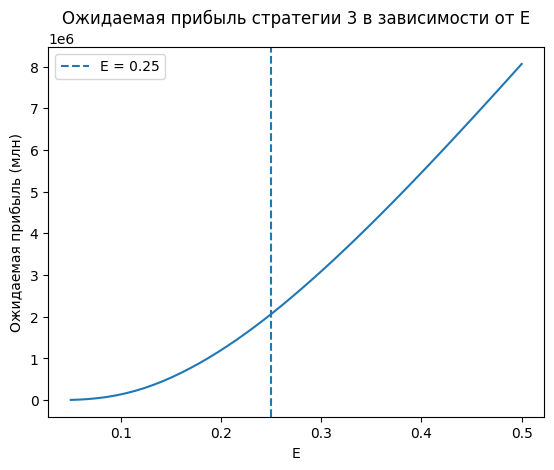

In [104]:
plt.plot(np.linspace(0.05, 0.5, 50), profits)
plt.axvline(0.25, linestyle="--", label="E = 0.25")

plt.xlabel("E")
plt.ylabel("Ожидаемая прибыль (млн)")
plt.title("Ожидаемая прибыль стратегии 3 в зависимости от E")
plt.legend()
plt.show()